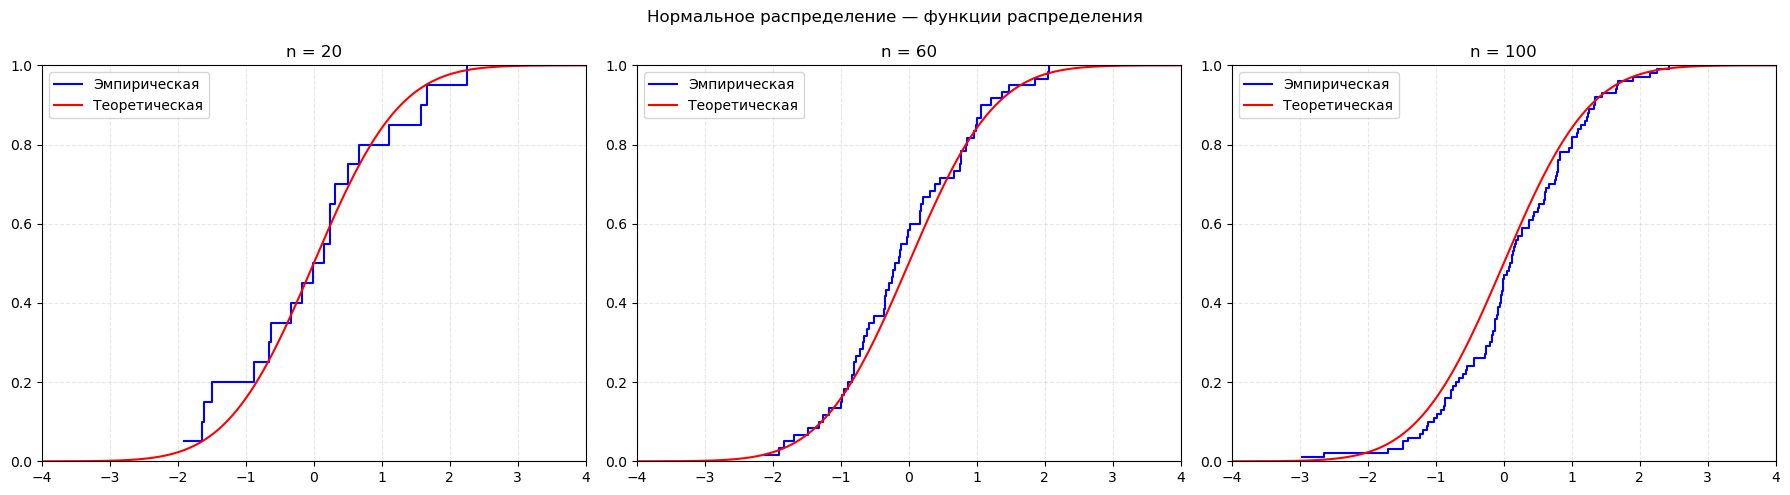

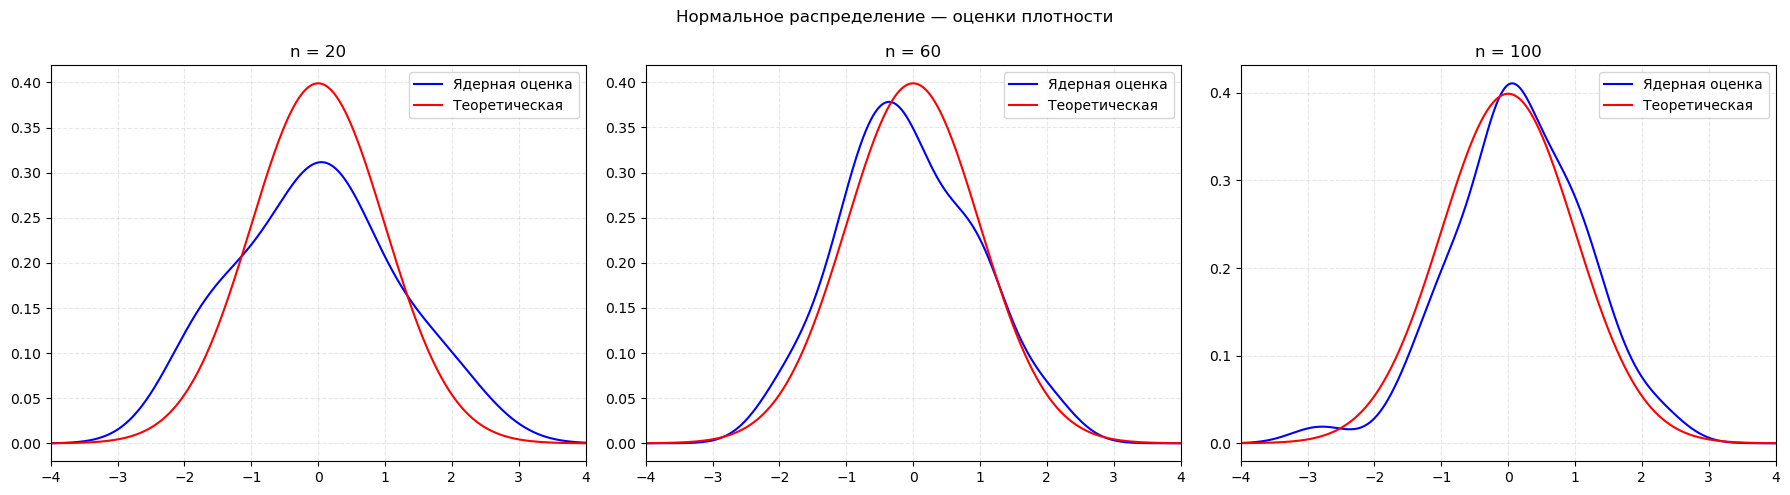

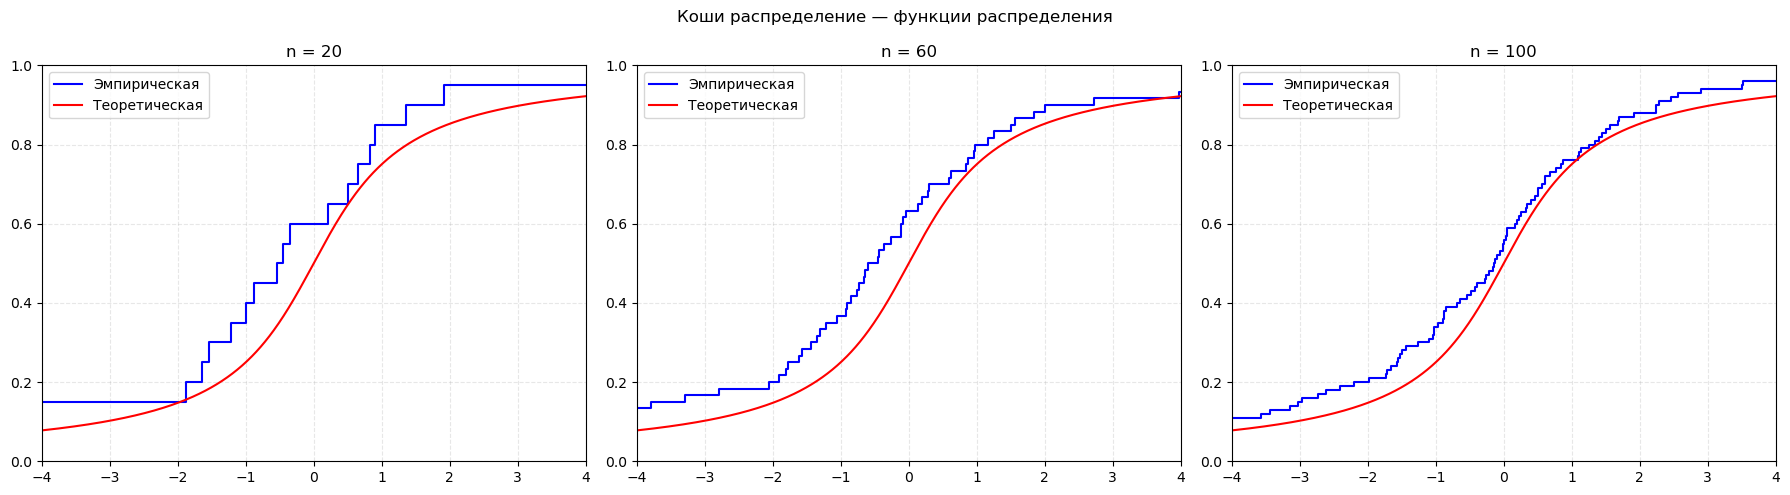

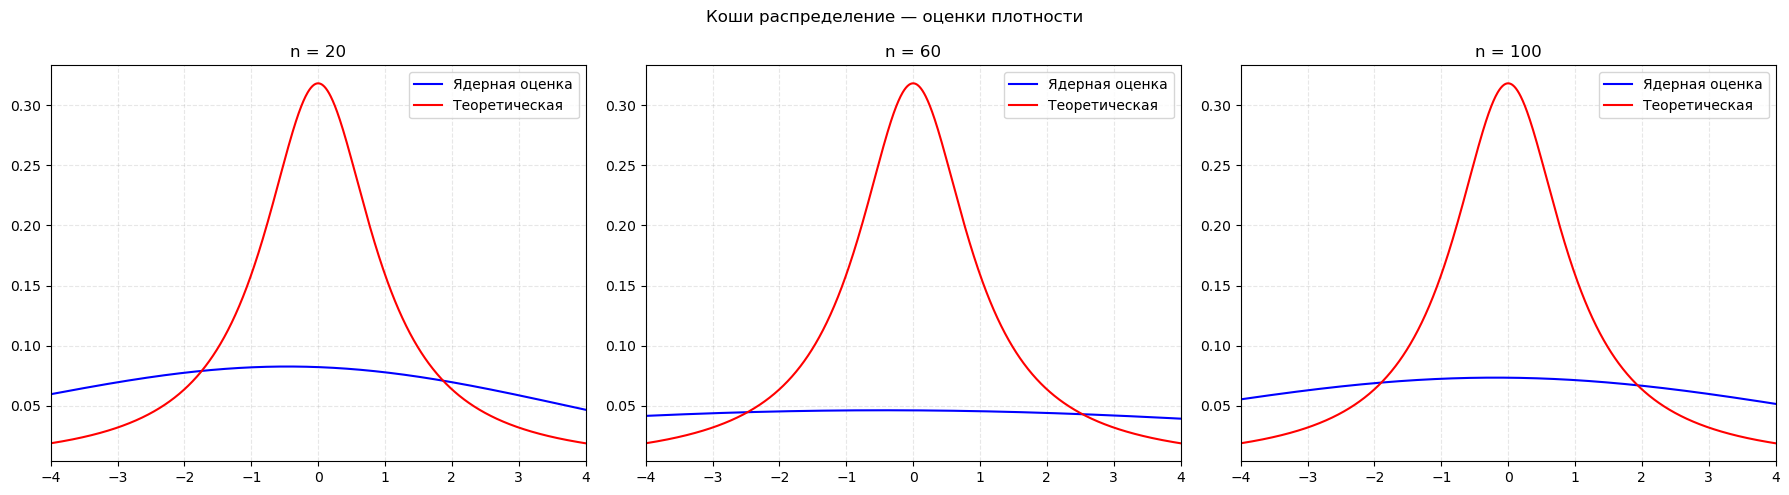

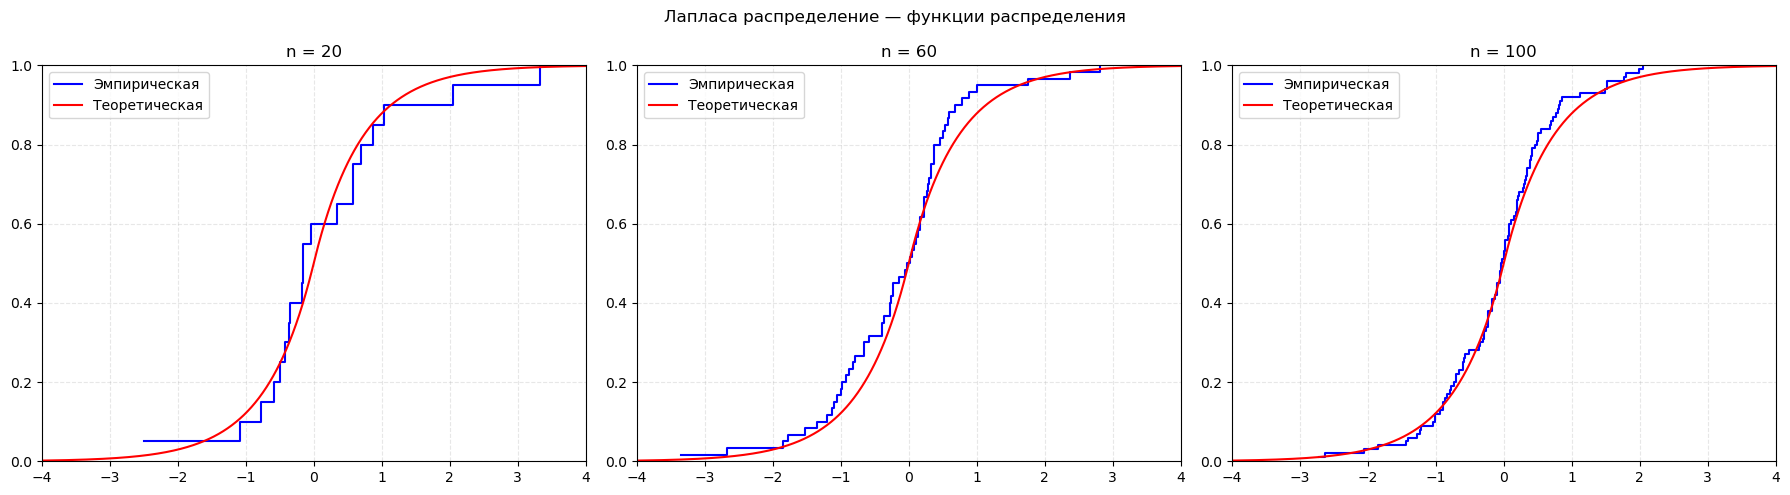

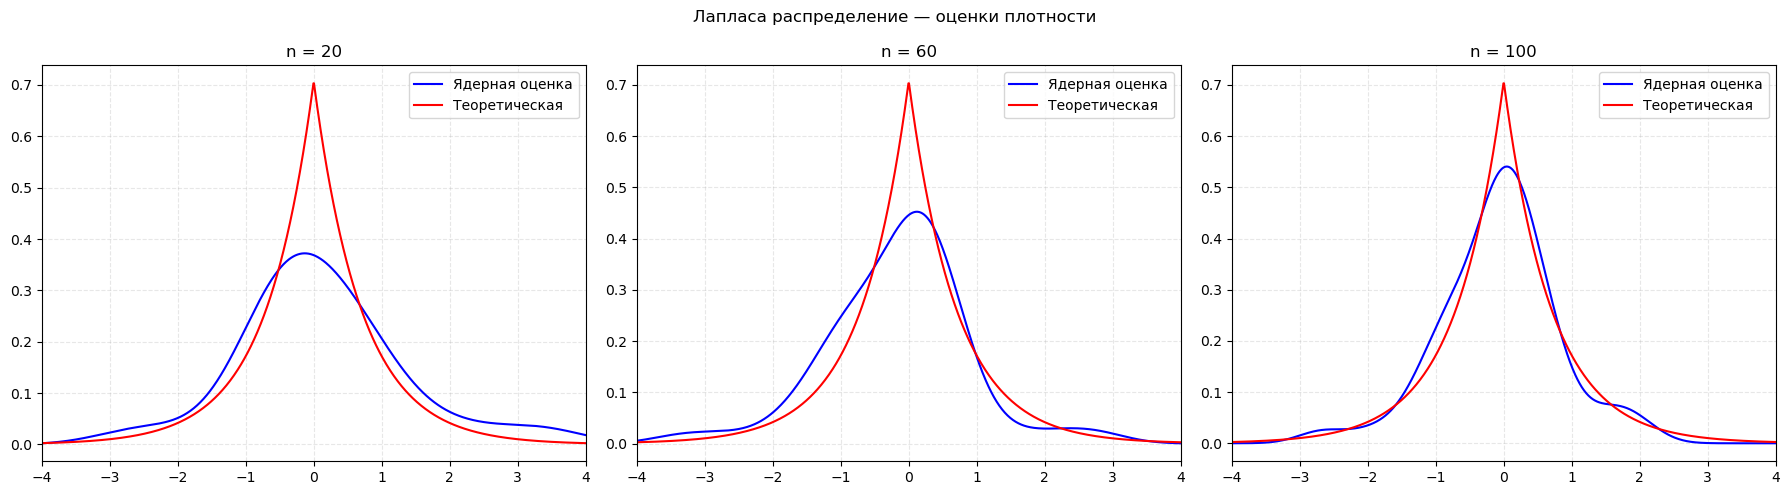

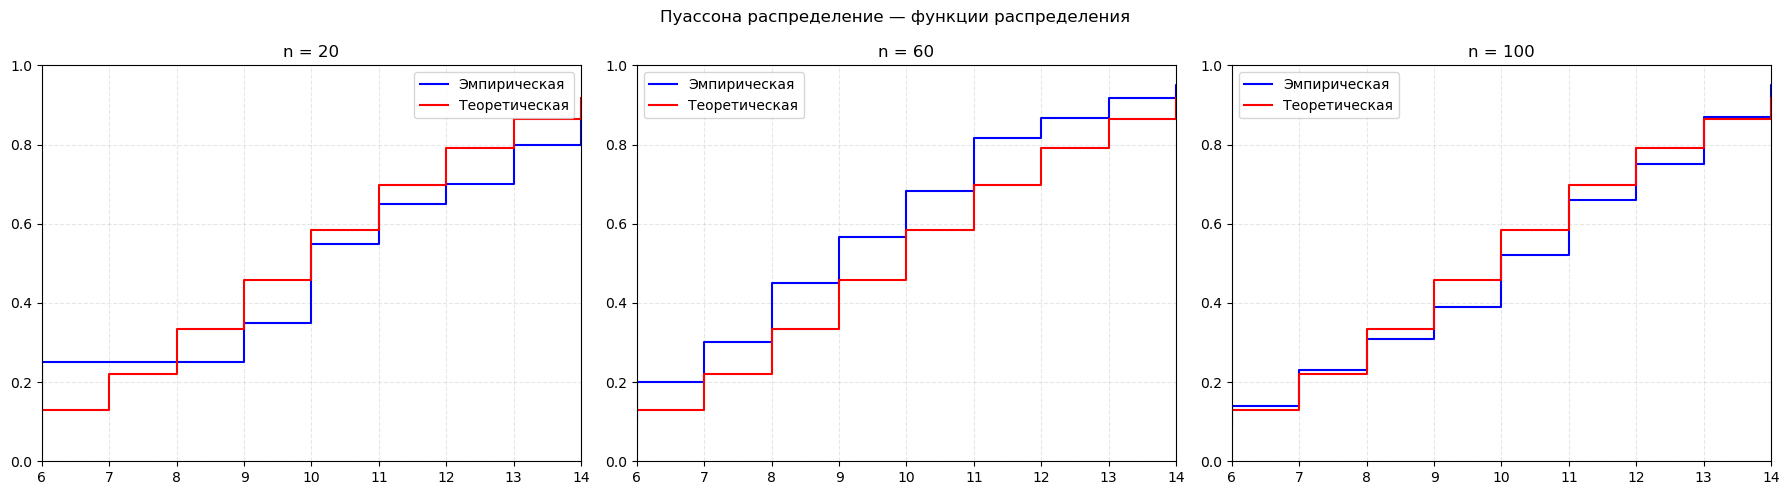

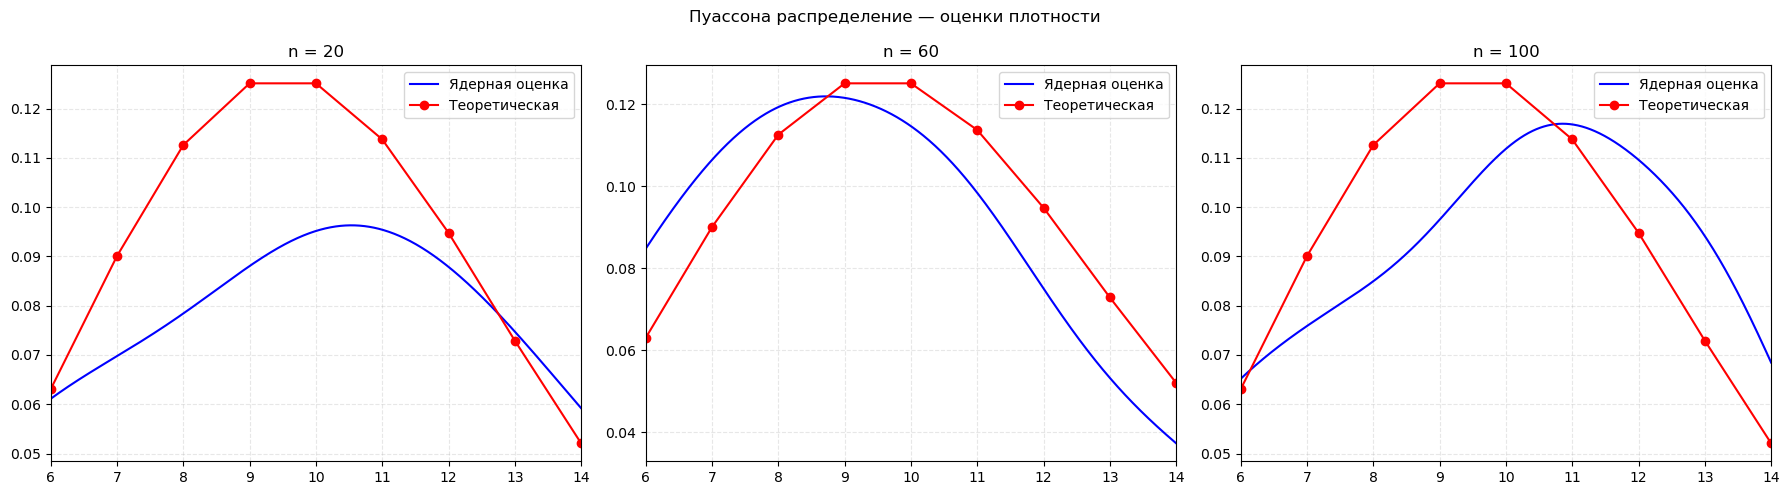

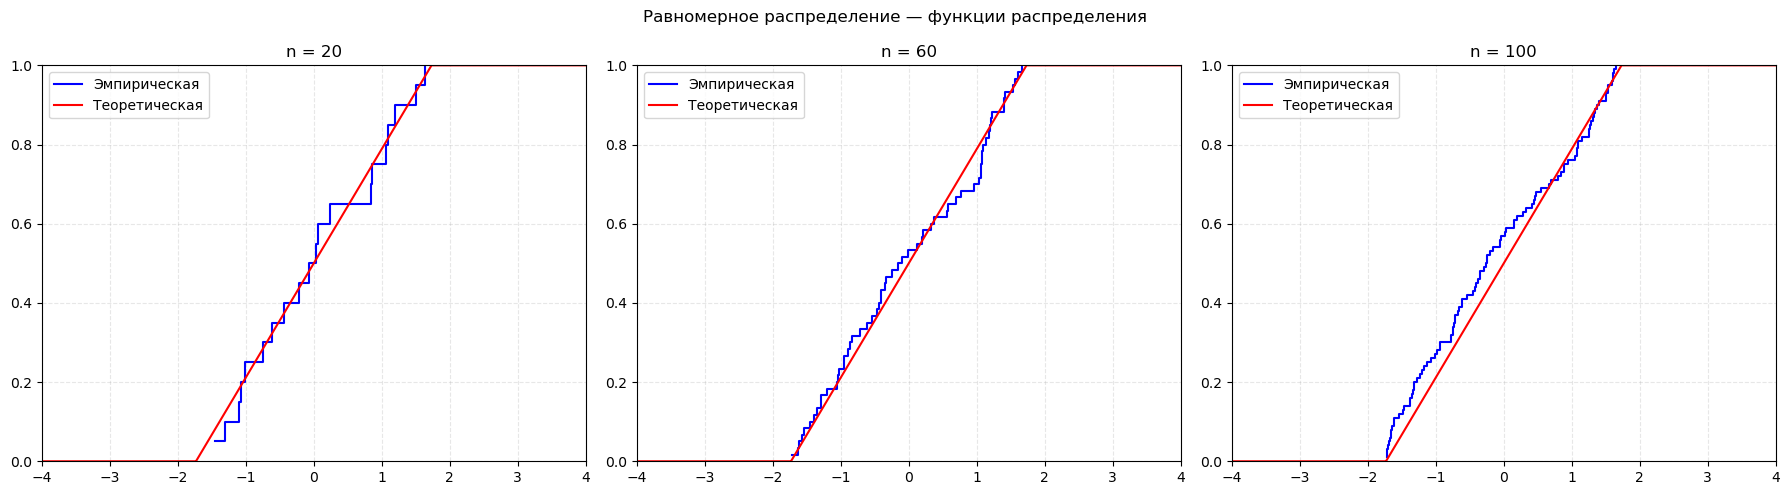

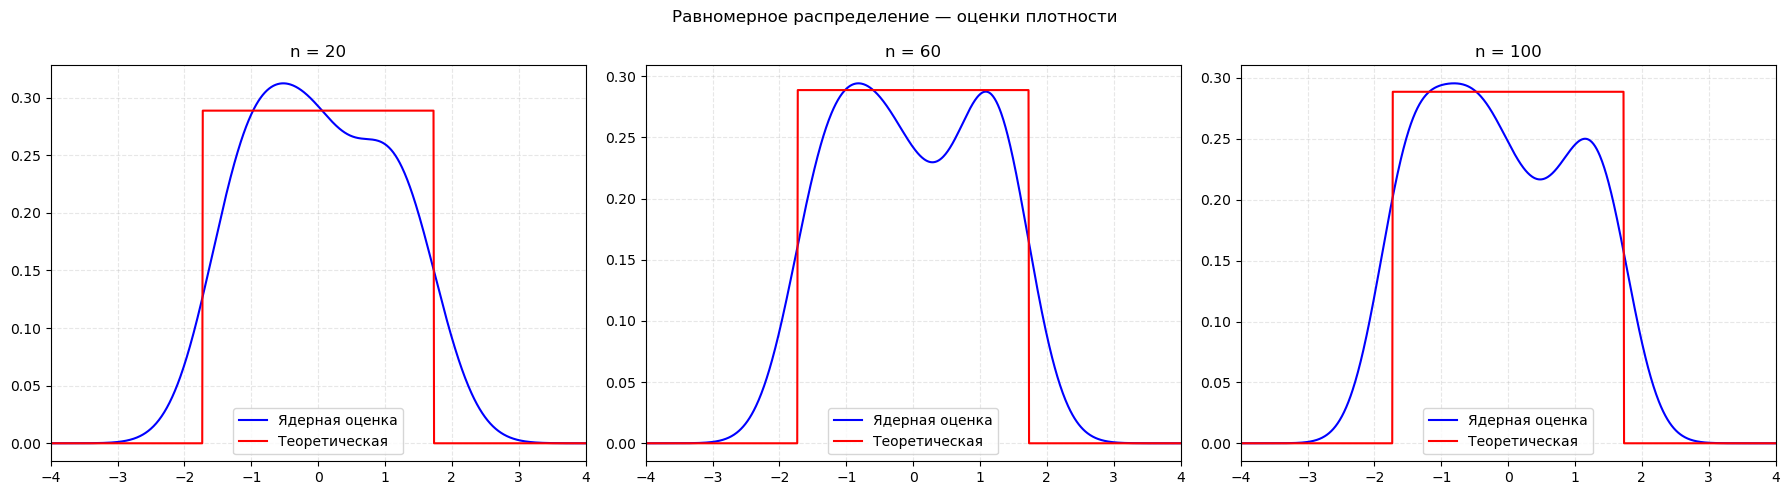

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


def plot_ecdf(samples, sizes, name):
    fig, axes = plt.subplots(1, len(sizes), figsize=(18, 5))

    for i, n in enumerate(sizes):
        ax = axes[i]
        sample = samples[i]

        x = np.sort(sample)
        y = np.arange(1, n + 1) / n

        ax.step(x, y, where="post", label="Эмпирическая", color="blue")

        if name == "Нормальное":
            grid = np.linspace(-4, 4, 1000)
            ax.plot(grid, stats.norm(0,1).cdf(grid), color="red", label="Теоретическая")

        elif name == "Коши":
            grid = np.linspace(-4, 4, 1000)
            ax.plot(grid, stats.cauchy().cdf(grid), color="red", label="Теоретическая")

        elif name == "Лапласа":
            grid = np.linspace(-4, 4, 1000)
            ax.plot(grid, stats.laplace(0,1/np.sqrt(2)).cdf(grid), color="red", label="Теоретическая")

        elif name == "Равномерное":
            grid = np.linspace(-4, 4, 1000)
            ax.plot(grid, stats.uniform(-np.sqrt(3), 2*np.sqrt(3)).cdf(grid), color="red", label="Теоретическая")

        elif name == "Пуассона":
            grid = np.arange(6, 15)
            ax.step(grid, stats.poisson(10).cdf(grid), where="post", color="red", label="Теоретическая")

        if name == "Пуассона":
            ax.set_xlim(6, 14)
        else:
            ax.set_xlim(-4, 4)

        ax.set_ylim(0, 1)
        ax.set_title(f"n = {n}")
        ax.grid(True, linestyle="--", alpha=0.3)
        ax.legend()

    fig.suptitle(f"{name} распределение — функции распределения")
    plt.tight_layout()
    plt.show()


def plot_kde(samples, sizes, name):
    fig, axes = plt.subplots(1, len(sizes), figsize=(18, 5))

    for i, n in enumerate(sizes):
        ax = axes[i]
        sample = samples[i]

        kde = stats.gaussian_kde(sample)

        if name == "Пуассона":

            x = np.arange(6, 15)
            grid = np.linspace(6, 14, 1000)

            ax.plot(grid, kde(grid), label="Ядерная оценка", color="blue")
            ax.plot(x, stats.poisson(10).pmf(x), "o-", color="red", label="Теоретическая")

            ax.set_xlim(6, 14)

        else:

            grid = np.linspace(-4, 4, 1000)

            ax.plot(grid, kde(grid), label="Ядерная оценка", color="blue")

            if name == "Нормальное":
                ax.plot(grid, stats.norm(0,1).pdf(grid), color="red", label="Теоретическая")

            elif name == "Коши":
                ax.plot(grid, stats.cauchy().pdf(grid), color="red", label="Теоретическая")

            elif name == "Лапласа":
                ax.plot(grid, stats.laplace(0,1/np.sqrt(2)).pdf(grid), color="red", label="Теоретическая")

            elif name == "Равномерное":
                ax.plot(grid, stats.uniform(-np.sqrt(3), 2*np.sqrt(3)).pdf(grid), color="red", label="Теоретическая")

            ax.set_xlim(-4, 4)

        ax.set_title(f"n = {n}")
        ax.grid(True, linestyle="--", alpha=0.3)
        ax.legend()

    fig.suptitle(f"{name} распределение — оценки плотности")
    plt.tight_layout()
    plt.show()


def run_lab4():
    rng = np.random.default_rng(4)

    sizes = [20, 60, 100]

    distributions = [
        ("Нормальное", lambda n: rng.normal(0, 1, n)),
        ("Коши", lambda n: rng.standard_cauchy(n)),
        ("Лапласа", lambda n: rng.laplace(0, 1/np.sqrt(2), n)),
        ("Пуассона", lambda n: rng.poisson(10, n)),
        ("Равномерное", lambda n: rng.uniform(-np.sqrt(3), np.sqrt(3), n)),
    ]

    for name, gen in distributions:

        samples = [gen(n) for n in sizes]

        plot_ecdf(samples, sizes, name)
        plot_kde(samples, sizes, name)


if __name__ == "__main__":
    run_lab4()